# EDA + K-Means Clustering
## Team Member 2 — Youngdong Highway Traffic Congestion Prediction
**Data Mining (ITM) | Northumbria University**

### Tasks
1. Speed distribution by segment / time zone / day of week
2. Holiday & snowfall pattern analysis
3. Threshold confirmation from data distribution
4. K-Means clustering (k=3)
5. Silhouette Score — label validity verification

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Brand color palette (matches project presentation style) ──
CORAL  = '#CC785C'
TEAL   = '#5DB8A6'
AMBER  = '#E8A55A'
INK    = '#141413'
MUTED  = '#6C6A64'
CANVAS = '#FAF9F5'
CARD   = '#EFE9DE'

LABEL_COLORS = {'smooth': TEAL, 'slow': AMBER, 'congested': CORAL}
LABEL_ORDER  = ['smooth', 'slow', 'congested']

SEG_NAMES = {
    'seg1': 'Seg 1 — Icheon (Urban)',
    'seg2': 'Seg 2 — Wonju (Inland)',
    'seg3': 'Seg 3 — Daegwallyeong (Mountain)'
}

plt.rcParams.update({
    'figure.facecolor': CANVAS,
    'axes.facecolor':   CARD,
    'axes.edgecolor':   '#E6DFD8',
    'axes.labelcolor':  INK,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       INK,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E6DFD8',
    'grid.linewidth':   0.6,
})

print('Setup complete.')

Setup complete.


---
## 1. Load Data

In [2]:
# ── Adjust paths if needed ──
DATA_PATHS = {
    'seg1': '../data/4_seg1_icheon_final.csv',
    'seg2': '../data/4_seg2_wonju_final.csv',
    'seg3': '../data/4_seg3_daegwallyeong_final.csv',
}

dfs = {key: pd.read_csv(path) for key, path in DATA_PATHS.items()}

for key, df in dfs.items():
    print(f'{SEG_NAMES[key]}')
    print(f'  Rows: {len(df):,}  |  Columns: {df.shape[1]}')
    print(f'  Label distribution:')
    for lbl in LABEL_ORDER:
        n = (df['label'] == lbl).sum()
        pct = n / len(df) * 100
        print(f'    {lbl:<12}: {n:>7,}  ({pct:.1f}%)')
    print()

Seg 1 — Icheon (Urban)
  Rows: 269,181  |  Columns: 19
  Label distribution:
    smooth      : 154,127  (57.3%)
    slow        :  98,879  (36.7%)
    congested   :  16,175  (6.0%)

Seg 2 — Wonju (Inland)
  Rows: 427,017  |  Columns: 19
  Label distribution:
    smooth      : 309,750  (72.5%)
    slow        : 111,409  (26.1%)
    congested   :   5,858  (1.4%)

Seg 3 — Daegwallyeong (Mountain)
  Rows: 465,030  |  Columns: 19
  Label distribution:
    smooth      : 354,803  (76.3%)
    slow        : 108,761  (23.4%)
    congested   :   1,466  (0.3%)



---
## 2. EDA — Label Distribution per Segment

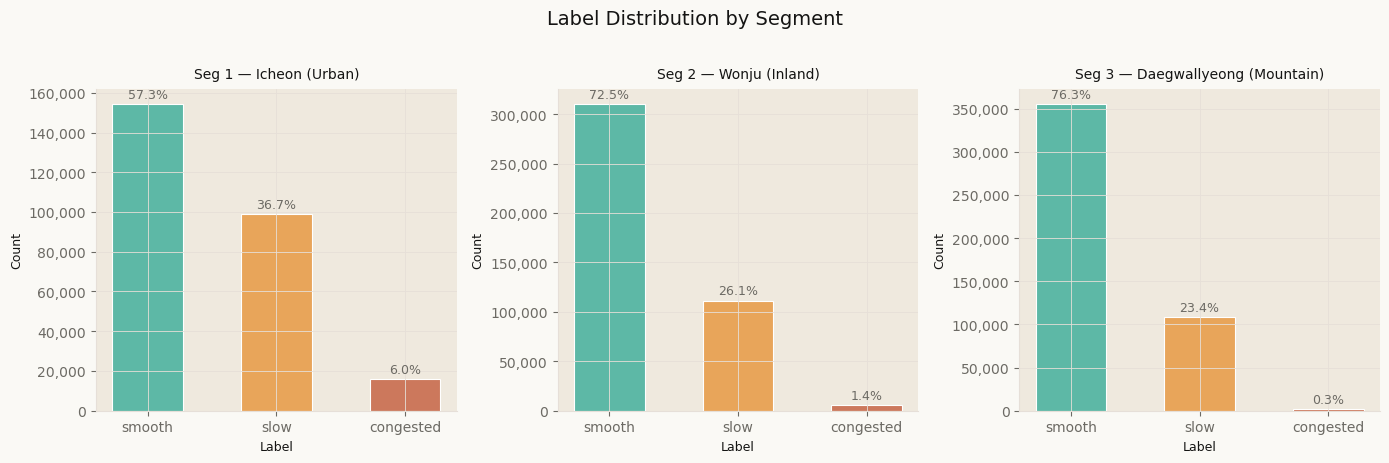

Saved: fig1_label_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Label Distribution by Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    counts = df['label'].value_counts().reindex(LABEL_ORDER)
    bars = ax.bar(
        LABEL_ORDER,
        counts.values,
        color=[LABEL_COLORS[l] for l in LABEL_ORDER],
        edgecolor='white', linewidth=0.8, width=0.55
    )
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9, color=MUTED)
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Label', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig1_label_distribution.png')

---
## 3. EDA — Congestion Pattern by Hour

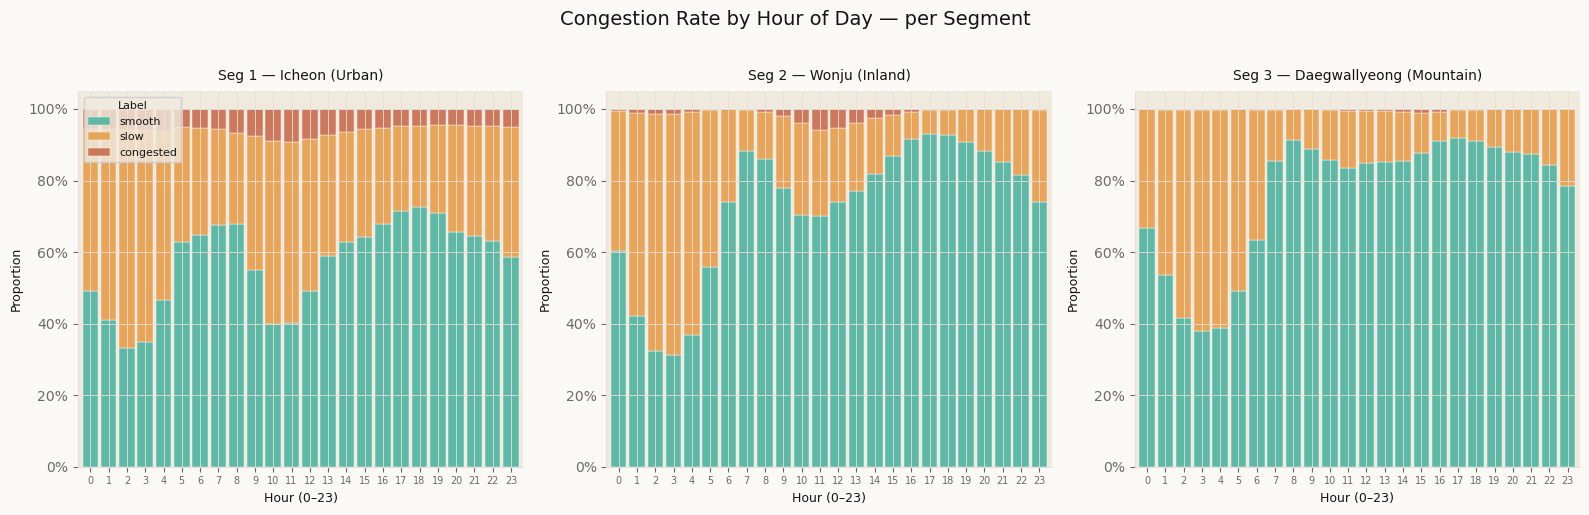

Saved: fig2_hourly_congestion.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Congestion Rate by Hour of Day — per Segment', fontsize=14, color=INK, y=1.02)

# hour is StandardScaler-normalized → decode back to 0-23 for display
# We'll use the normalized value to group, but label x-axis as 0-23

for ax, (key, df) in zip(axes, dfs.items()):
    # Get approximate hour bins: sort unique values → map to 0-23
    hour_vals = sorted(df['hour'].unique())
    hour_map = {v: i for i, v in enumerate(hour_vals)}
    df_plot = df.copy()
    df_plot['hour_bin'] = df_plot['hour'].map(hour_map)

    pivot = df_plot.groupby('hour_bin')['label'].value_counts(normalize=True).unstack(fill_value=0)
    for lbl in LABEL_ORDER:
        if lbl not in pivot.columns:
            pivot[lbl] = 0
    pivot = pivot[LABEL_ORDER]

    pivot.plot(
        kind='bar', stacked=True, ax=ax, width=0.85,
        color=[LABEL_COLORS[l] for l in LABEL_ORDER],
        edgecolor='white', linewidth=0.3, legend=(key == 'seg1')
    )
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Hour (0–23)', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_xticklabels([str(h) for h in range(len(hour_vals))], rotation=0, fontsize=7)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    if key == 'seg1':
        ax.legend(title='Label', fontsize=8, title_fontsize=8,
                  loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.savefig('fig2_hourly_congestion.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig2_hourly_congestion.png')

---
## 4. EDA — Congestion Pattern by Day of Week

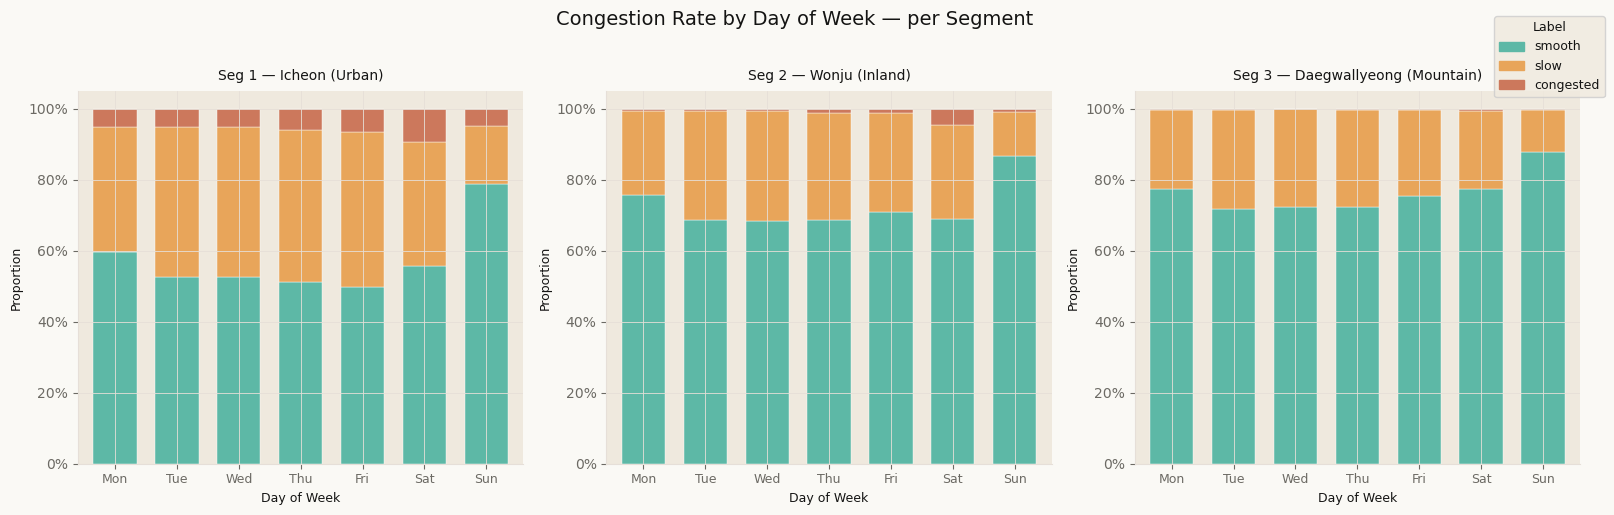

Saved: fig3_dayofweek_congestion.png


In [5]:
DAY_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Congestion Rate by Day of Week — per Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    dow_vals = sorted(df['dayofweek'].unique())
    dow_map = {v: i for i, v in enumerate(dow_vals)}
    df_plot = df.copy()
    df_plot['dow_bin'] = df_plot['dayofweek'].map(dow_map)

    pivot = df_plot.groupby('dow_bin')['label'].value_counts(normalize=True).unstack(fill_value=0)
    for lbl in LABEL_ORDER:
        if lbl not in pivot.columns:
            pivot[lbl] = 0
    pivot = pivot[LABEL_ORDER]

    pivot.plot(
        kind='bar', stacked=True, ax=ax, width=0.7,
        color=[LABEL_COLORS[l] for l in LABEL_ORDER],
        edgecolor='white', linewidth=0.3, legend=False
    )
    n_days = len(dow_vals)
    ax.set_xticklabels(DAY_LABELS[:n_days], rotation=0, fontsize=9)
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Day of Week', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# shared legend
handles = [plt.Rectangle((0,0),1,1, color=LABEL_COLORS[l]) for l in LABEL_ORDER]
fig.legend(handles, LABEL_ORDER, loc='upper right', fontsize=9,
           title='Label', title_fontsize=9, bbox_to_anchor=(1.01, 1.02))

plt.tight_layout()
plt.savefig('fig3_dayofweek_congestion.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig3_dayofweek_congestion.png')

---
## 5. EDA — Time Zone Effect

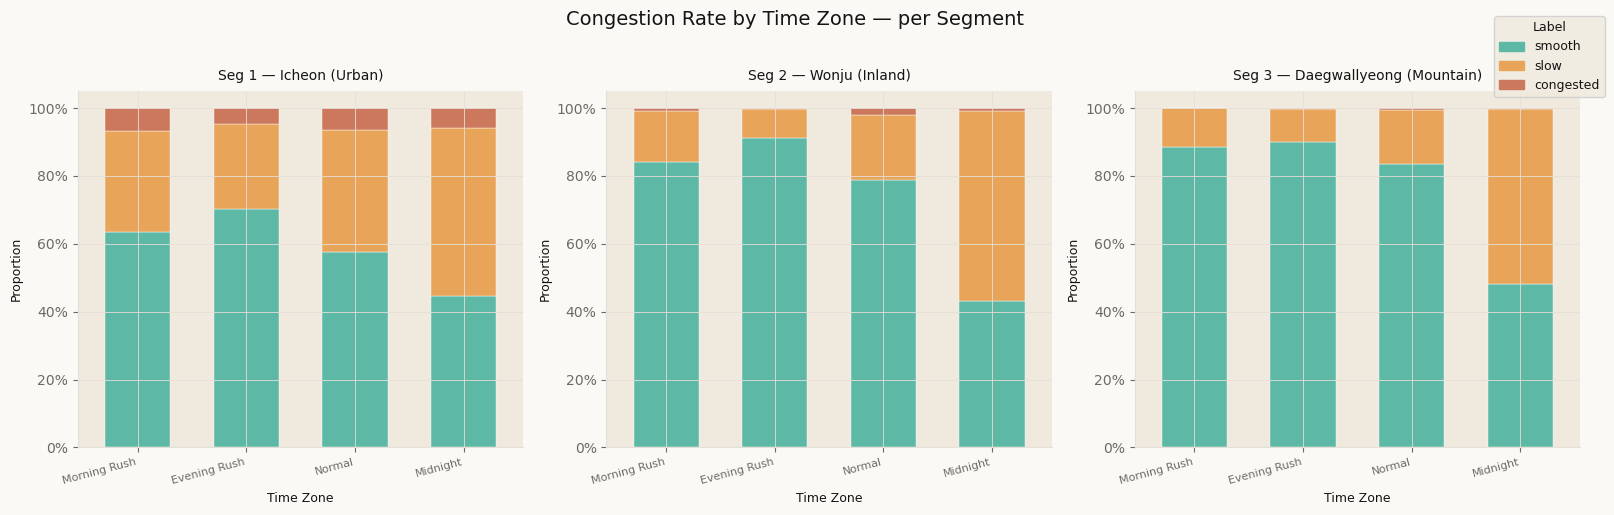

Saved: fig4_timezone_congestion.png


In [6]:
TIME_ZONE_COLS = ['time_zone_morning_rush', 'time_zone_evening_rush',
                  'time_zone_midnight', 'time_zone_normal']
TZ_DISPLAY = {'time_zone_morning_rush': 'Morning Rush',
               'time_zone_evening_rush': 'Evening Rush',
               'time_zone_midnight':     'Midnight',
               'time_zone_normal':       'Normal'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Congestion Rate by Time Zone — per Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    # decode OHE back to a single column
    def get_tz(row):
        for col in TIME_ZONE_COLS:
            if row[col] == 1:
                return TZ_DISPLAY[col]
        return 'Normal'
    df_plot = df.copy()
    df_plot['time_zone'] = df_plot.apply(get_tz, axis=1)

    tz_order = ['Morning Rush', 'Evening Rush', 'Normal', 'Midnight']
    pivot = df_plot.groupby('time_zone')['label'].value_counts(normalize=True).unstack(fill_value=0)
    pivot = pivot.reindex(tz_order).fillna(0)[LABEL_ORDER]

    pivot.plot(
        kind='bar', stacked=True, ax=ax, width=0.6,
        color=[LABEL_COLORS[l] for l in LABEL_ORDER],
        edgecolor='white', linewidth=0.3, legend=False
    )
    ax.set_xticklabels(tz_order, rotation=15, ha='right', fontsize=8)
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Time Zone', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [plt.Rectangle((0,0),1,1, color=LABEL_COLORS[l]) for l in LABEL_ORDER]
fig.legend(handles, LABEL_ORDER, loc='upper right', fontsize=9,
           title='Label', title_fontsize=9, bbox_to_anchor=(1.01, 1.02))

plt.tight_layout()
plt.savefig('fig4_timezone_congestion.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig4_timezone_congestion.png')

---
## 6. EDA — Holiday & Weekend Effect

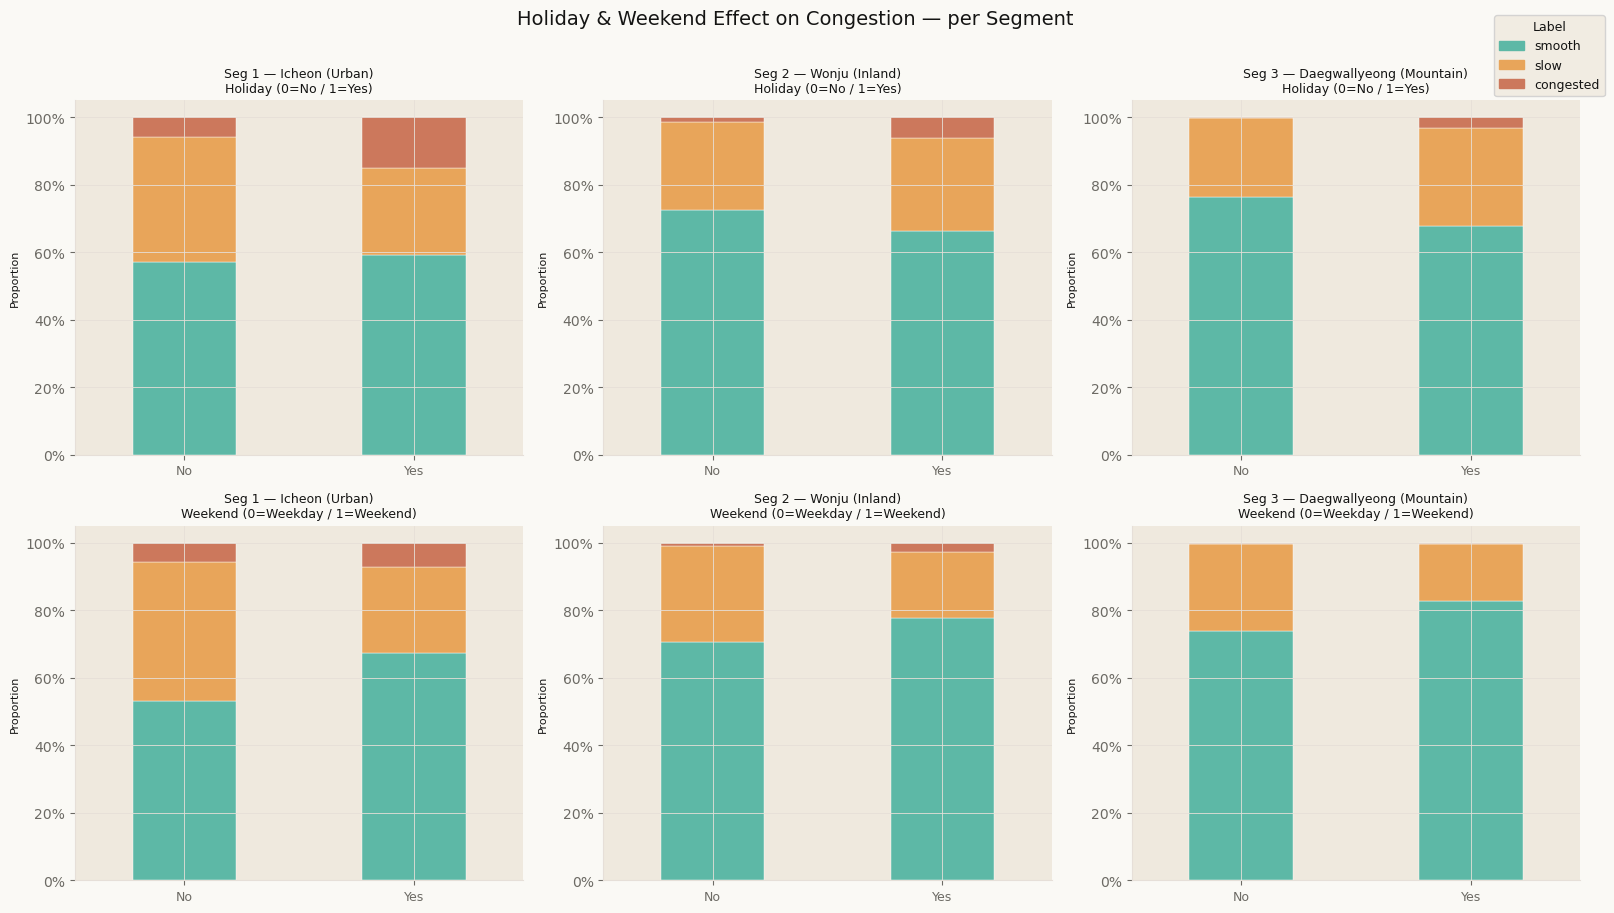

Saved: fig5_holiday_weekend.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Holiday & Weekend Effect on Congestion — per Segment', fontsize=14, color=INK, y=1.01)

for col_idx, (key, df) in enumerate(dfs.items()):
    for row_idx, (col_name, col_title) in enumerate([('is_holiday', 'Holiday (0=No / 1=Yes)'),
                                                      ('is_weekend', 'Weekend (0=Weekday / 1=Weekend)')]):
        ax = axes[row_idx][col_idx]
        pivot = df.groupby(col_name)['label'].value_counts(normalize=True).unstack(fill_value=0)
        for lbl in LABEL_ORDER:
            if lbl not in pivot.columns:
                pivot[lbl] = 0
        pivot = pivot[LABEL_ORDER]
        pivot.plot(
            kind='bar', stacked=True, ax=ax, width=0.45,
            color=[LABEL_COLORS[l] for l in LABEL_ORDER],
            edgecolor='white', linewidth=0.3, legend=False
        )
        ax.set_title(f'{SEG_NAMES[key]}\n{col_title}', fontsize=9, color=INK, pad=6)
        ax.set_xlabel('', fontsize=8)
        ax.set_ylabel('Proportion', fontsize=8)
        ax.set_xticklabels(['No', 'Yes'], rotation=0, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [plt.Rectangle((0,0),1,1, color=LABEL_COLORS[l]) for l in LABEL_ORDER]
fig.legend(handles, LABEL_ORDER, loc='upper right', fontsize=9,
           title='Label', title_fontsize=9, bbox_to_anchor=(1.01, 1.01))

plt.tight_layout()
plt.savefig('fig5_holiday_weekend.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig5_holiday_weekend.png')

---
## 7. EDA — Snowfall Pattern (Seg 3 Focus)

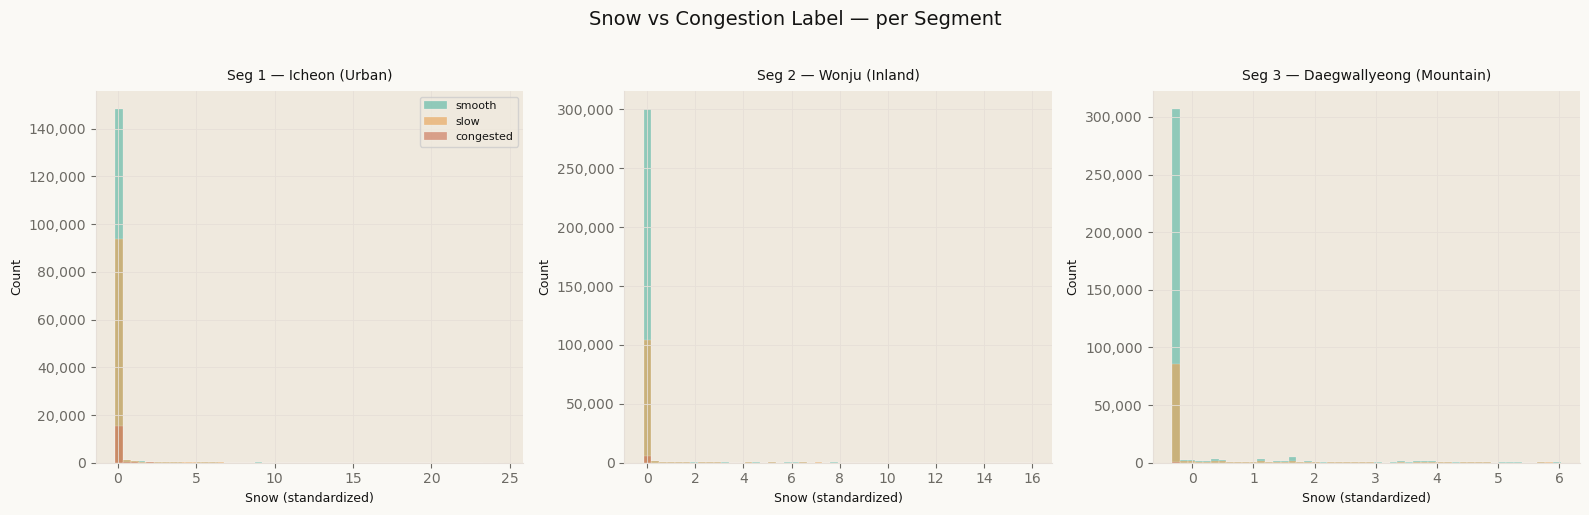

Saved: fig6_snow_distribution.png

Snow stats by segment and label:

Seg 1 — Icheon (Urban)
            mean    std     max
label                          
congested  0.079  1.442  24.265
slow       0.038  1.168  24.622
smooth    -0.032  0.806  23.285

Seg 2 — Wonju (Inland)
            mean    std     max
label                          
congested  0.125  1.411  16.011
slow       0.133  1.467  16.011
smooth    -0.050  0.747  16.011

Seg 3 — Daegwallyeong (Mountain)
            mean    std    max
label                         
congested  0.190  1.128  5.873
slow       0.120  1.146  6.018
smooth    -0.038  0.947  6.018


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Snow vs Congestion Label — per Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    for lbl in LABEL_ORDER:
        subset = df[df['label'] == lbl]['snow']
        ax.hist(subset, bins=50, alpha=0.65, label=lbl,
                color=LABEL_COLORS[lbl], edgecolor='white', linewidth=0.2)
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Snow (standardized)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    if key == 'seg1':
        ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('fig6_snow_distribution.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig6_snow_distribution.png')
print()
print('Snow stats by segment and label:')
for key, df in dfs.items():
    print(f'\n{SEG_NAMES[key]}')
    print(df.groupby('label')['snow'].describe()[['mean','std','max']].round(3).to_string())

---
## 8. EDA — Season Effect

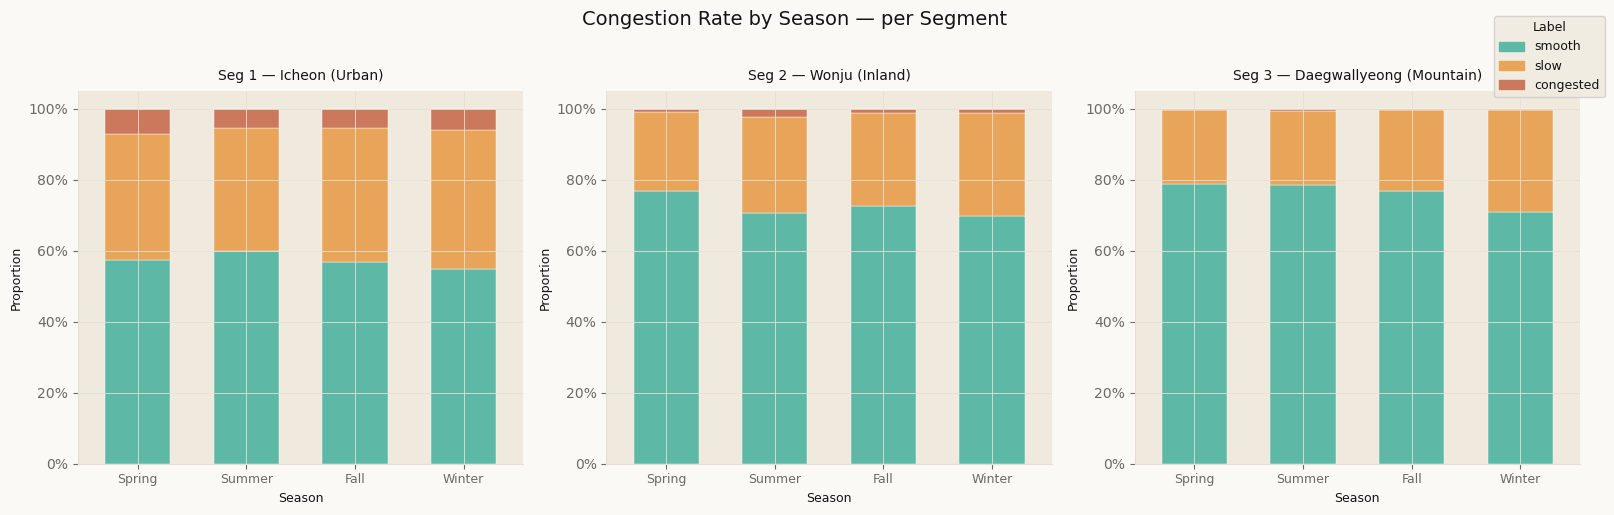

Saved: fig7_season_congestion.png


In [9]:
SEASON_COLS = ['season_spring', 'season_summer', 'season_fall', 'season_winter']
SEASON_NAMES = {'season_spring': 'Spring', 'season_summer': 'Summer',
                'season_fall': 'Fall',   'season_winter': 'Winter'}
SEASON_ORDER = ['Spring', 'Summer', 'Fall', 'Winter']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Congestion Rate by Season — per Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    def get_season(row):
        for col in SEASON_COLS:
            if row[col] == 1:
                return SEASON_NAMES[col]
        return 'Spring'
    df_plot = df.copy()
    df_plot['season'] = df_plot.apply(get_season, axis=1)

    pivot = df_plot.groupby('season')['label'].value_counts(normalize=True).unstack(fill_value=0)
    pivot = pivot.reindex(SEASON_ORDER).fillna(0)[LABEL_ORDER]

    pivot.plot(
        kind='bar', stacked=True, ax=ax, width=0.6,
        color=[LABEL_COLORS[l] for l in LABEL_ORDER],
        edgecolor='white', linewidth=0.3, legend=False
    )
    ax.set_xticklabels(SEASON_ORDER, rotation=0, fontsize=9)
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Season', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [plt.Rectangle((0,0),1,1, color=LABEL_COLORS[l]) for l in LABEL_ORDER]
fig.legend(handles, LABEL_ORDER, loc='upper right', fontsize=9,
           title='Label', title_fontsize=9, bbox_to_anchor=(1.01, 1.02))

plt.tight_layout()
plt.savefig('fig7_season_congestion.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig7_season_congestion.png')

---
## 9. EDA — Correlation Heatmap (Weather Features)

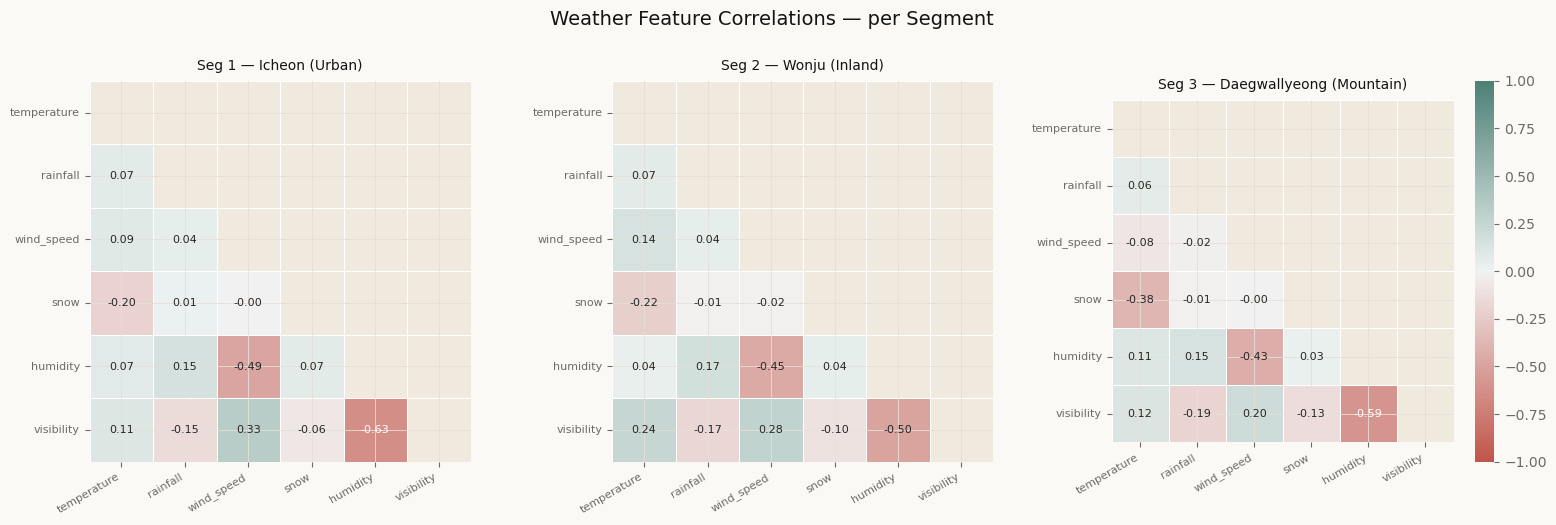

Saved: fig8_weather_correlation.png


In [11]:
WEATHER_COLS = ['temperature', 'rainfall', 'wind_speed', 'snow', 'humidity', 'visibility']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Weather Feature Correlations — per Segment', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    corr = df[WEATHER_COLS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax, annot=True, fmt='.2f', annot_kws={'size': 8},
        cmap=sns.diverging_palette(16, 171, s=60, as_cmap=True),  # coral ↔ teal
        vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
        cbar=(key == 'seg3'), square=True
    )
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('fig8_weather_correlation.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig8_weather_correlation.png')

---
## 10. Threshold Confirmation
The team used **±1σ** from the mean to set the label thresholds.
Here we verify the threshold values match the label distribution.

In [12]:
# Thresholds applied by Team Member 1 (from preprocessing report)
THRESHOLDS = {'smooth': 95, 'slow_upper': 95, 'slow_lower': 60, 'congested': 60}

print('=== Label Distribution vs. ±1σ Threshold Confirmation ===')
print()
for key, df in dfs.items():
    print(f'{SEG_NAMES[key]}')
    dist = df['label'].value_counts(normalize=True) * 100
    print(f'  smooth    : {dist.get("smooth",0):.1f}%  (speed ≥ 95 km/h)')
    print(f'  slow      : {dist.get("slow",0):.1f}%  (60 ≤ speed < 95 km/h)')
    print(f'  congested : {dist.get("congested",0):.1f}%  (speed < 60 km/h)')
    print(f'  → Class imbalance ratio (smooth:congested) = {dist.get("smooth",0)/max(dist.get("congested",0.001),0.001):.1f}x')
    print()

print('Note: Thresholds 60/95 km/h are based on data distribution (mean 92.6, std 25.1).')
print('This deviates from official KoROAD standards (40/80) to better reflect actual speed spread.')

=== Label Distribution vs. ±1σ Threshold Confirmation ===

Seg 1 — Icheon (Urban)
  smooth    : 57.3%  (speed ≥ 95 km/h)
  slow      : 36.7%  (60 ≤ speed < 95 km/h)
  congested : 6.0%  (speed < 60 km/h)
  → Class imbalance ratio (smooth:congested) = 9.5x

Seg 2 — Wonju (Inland)
  smooth    : 72.5%  (speed ≥ 95 km/h)
  slow      : 26.1%  (60 ≤ speed < 95 km/h)
  congested : 1.4%  (speed < 60 km/h)
  → Class imbalance ratio (smooth:congested) = 52.9x

Seg 3 — Daegwallyeong (Mountain)
  smooth    : 76.3%  (speed ≥ 95 km/h)
  slow      : 23.4%  (60 ≤ speed < 95 km/h)
  congested : 0.3%  (speed < 60 km/h)
  → Class imbalance ratio (smooth:congested) = 242.0x

Note: Thresholds 60/95 km/h are based on data distribution (mean 92.6, std 25.1).
This deviates from official KoROAD standards (40/80) to better reflect actual speed spread.


---
## 11. K-Means Clustering (k=3)
### Goal: Verify that data naturally forms 3 clusters matching our label thresholds.

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURE_COLS = [
    'temperature', 'rainfall', 'wind_speed', 'snow', 'humidity', 'visibility',
    'hour', 'dayofweek', 'is_weekend', 'is_holiday',
    'time_zone_morning_rush', 'time_zone_evening_rush',
    'time_zone_midnight', 'time_zone_normal',
    'season_spring', 'season_summer', 'season_fall', 'season_winter'
]

# Use a sample for speed (50k rows per segment is sufficient)
SAMPLE_SIZE = 50_000
RANDOM_STATE = 42

kmeans_results = {}

for key, df in dfs.items():
    print(f'Running k-Means on {SEG_NAMES[key]} ...')
    sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
    X = sample[FEATURE_COLS].values

    km = KMeans(n_clusters=3, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels_km = km.fit_predict(X)

    sil = silhouette_score(X, labels_km, sample_size=10_000, random_state=RANDOM_STATE)
    inertia = km.inertia_

    kmeans_results[key] = {
        'model': km,
        'labels': labels_km,
        'true_labels': sample['label'].values,
        'X': X,
        'silhouette': sil,
        'inertia': inertia
    }
    print(f'  Silhouette Score : {sil:.4f}')
    print(f'  Inertia          : {inertia:,.0f}')
    print()

Running k-Means on Seg 1 — Icheon (Urban) ...
  Silhouette Score : 0.1935
  Inertia          : 361,959

Running k-Means on Seg 2 — Wonju (Inland) ...
  Silhouette Score : 0.1850
  Inertia          : 370,499

Running k-Means on Seg 3 — Daegwallyeong (Mountain) ...
  Silhouette Score : 0.1742
  Inertia          : 366,211



---
## 12. Elbow Curve — Confirm k=3 is Optimal

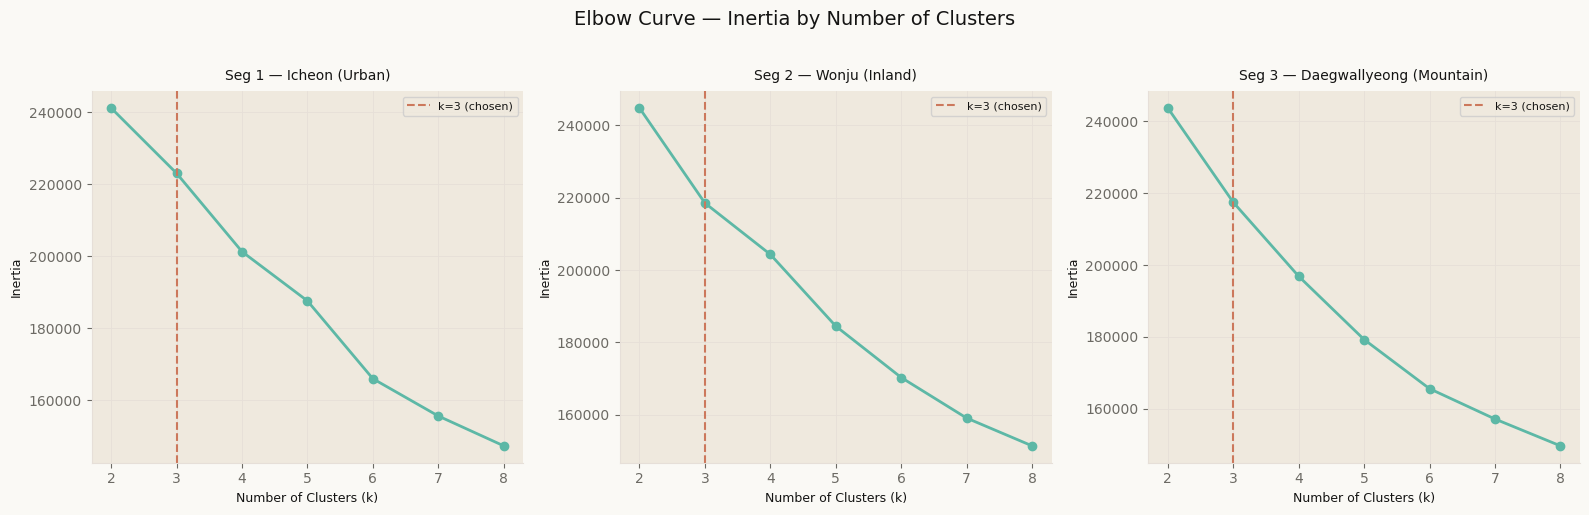

Saved: fig9_elbow_curve.png


In [14]:
K_RANGE = range(2, 9)
ELBOW_SAMPLE = 30_000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('Elbow Curve — Inertia by Number of Clusters', fontsize=14, color=INK, y=1.02)

for ax, (key, df) in zip(axes, dfs.items()):
    sample = df.sample(min(ELBOW_SAMPLE, len(df)), random_state=RANDOM_STATE)
    X = sample[FEATURE_COLS].values

    inertias = []
    for k in K_RANGE:
        km_tmp = KMeans(n_clusters=k, init='k-means++', n_init=5,
                        max_iter=200, random_state=RANDOM_STATE)
        km_tmp.fit(X)
        inertias.append(km_tmp.inertia_)

    ax.plot(list(K_RANGE), inertias, marker='o', color=TEAL, linewidth=2, markersize=6)
    ax.axvline(x=3, color=CORAL, linestyle='--', linewidth=1.5, label='k=3 (chosen)')
    ax.set_title(SEG_NAMES[key], fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Number of Clusters (k)', fontsize=9)
    ax.set_ylabel('Inertia', fontsize=9)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x:.0f}'))

plt.tight_layout()
plt.savefig('fig9_elbow_curve.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig9_elbow_curve.png')

---
## 13. Silhouette Score — All 3 Segments Summary

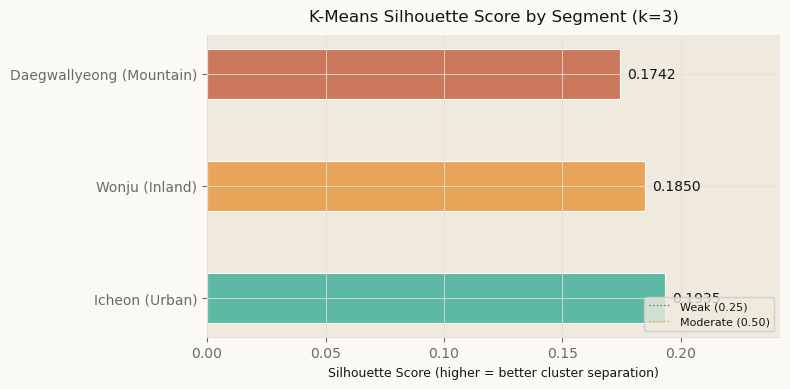

Saved: fig10_silhouette_scores.png

Interpretation:
  Seg 1 — Icheon (Urban): 0.1935 → Weak separation — clusters overlap in feature space
  Seg 2 — Wonju (Inland): 0.1850 → Weak separation — clusters overlap in feature space
  Seg 3 — Daegwallyeong (Mountain): 0.1742 → Weak separation — clusters overlap in feature space


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(CANVAS)

seg_labels = [SEG_NAMES[k].split('—')[1].strip() for k in kmeans_results]
sil_scores = [v['silhouette'] for v in kmeans_results.values()]
bar_colors = [TEAL, AMBER, CORAL]

bars = ax.barh(seg_labels, sil_scores, color=bar_colors,
               edgecolor='white', linewidth=0.8, height=0.45)

for bar, val in zip(bars, sil_scores):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, color=INK)

ax.set_xlim(0, max(sil_scores) * 1.25)
ax.set_xlabel('Silhouette Score (higher = better cluster separation)', fontsize=9)
ax.set_title('K-Means Silhouette Score by Segment (k=3)', fontsize=12, color=INK, pad=10)

# Reference lines
ax.axvline(0.25, color=MUTED, linestyle=':', linewidth=1, label='Weak (0.25)')
ax.axvline(0.50, color=AMBER, linestyle=':', linewidth=1, label='Moderate (0.50)')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig10_silhouette_scores.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig10_silhouette_scores.png')
print()
print('Interpretation:')
for key, res in kmeans_results.items():
    s = res['silhouette']
    if s >= 0.5:
        interp = 'Strong separation — label thresholds well supported'
    elif s >= 0.25:
        interp = 'Moderate separation — thresholds reasonably supported'
    else:
        interp = 'Weak separation — clusters overlap in feature space'
    print(f'  {SEG_NAMES[key]}: {s:.4f} → {interp}')

---
## 14. PCA Visualization — K-Means Clusters vs True Labels

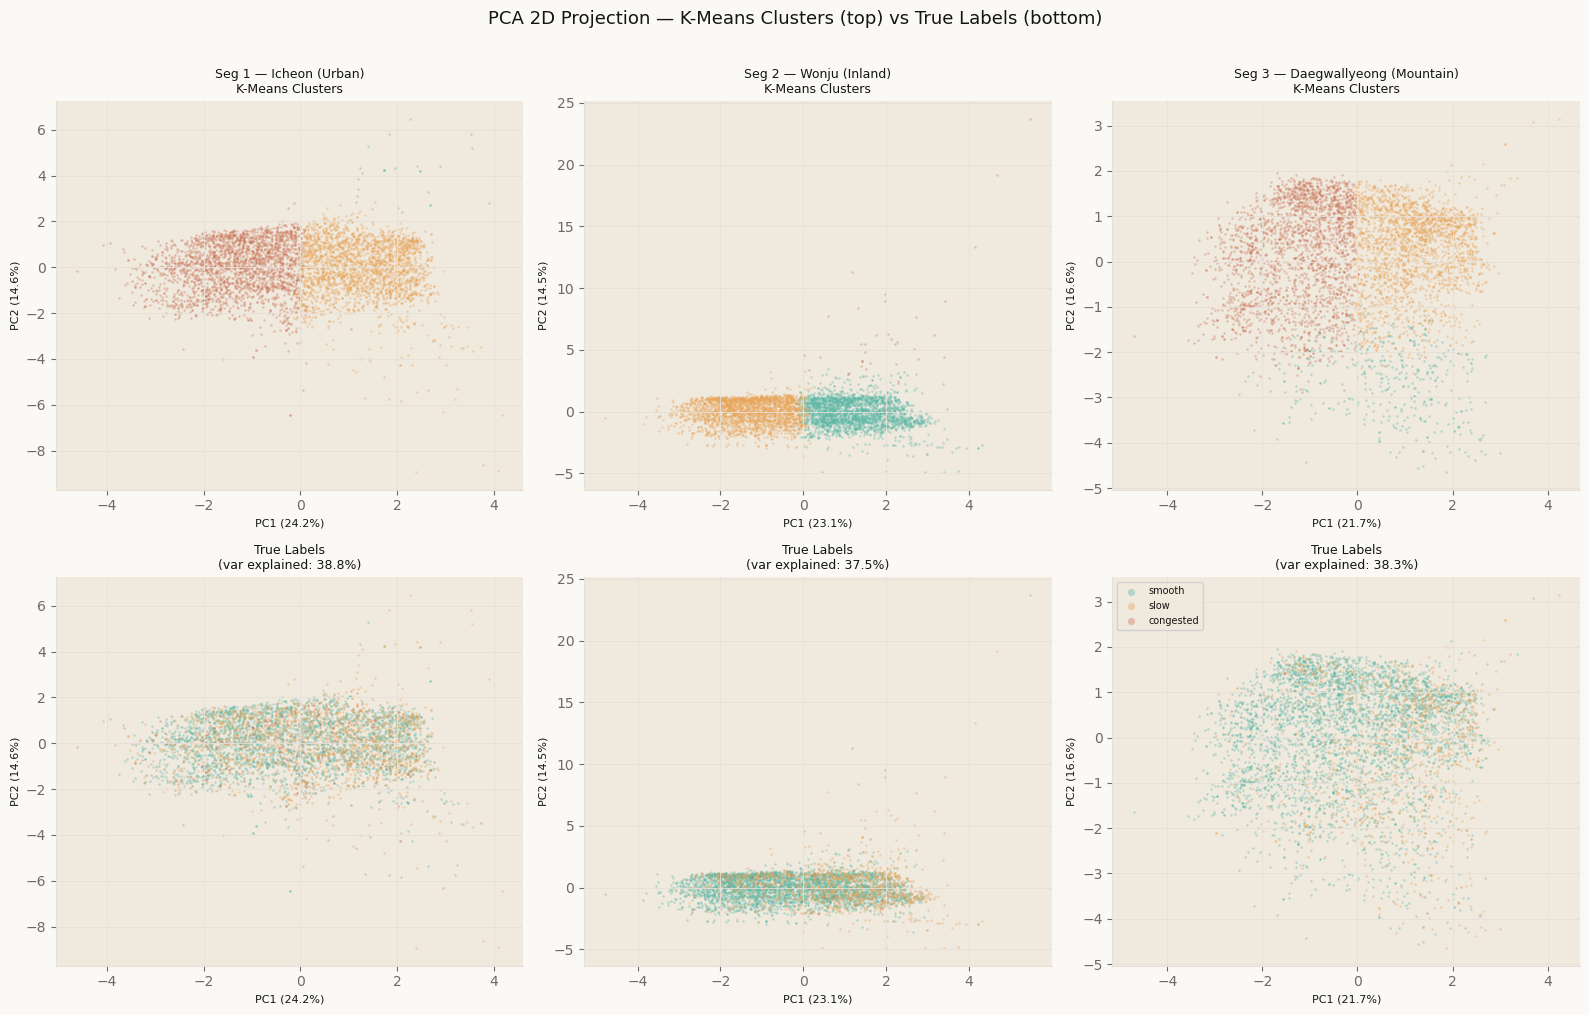

Saved: fig11_pca_visualization.png

Note: PCA is used here ONLY for 2D visualization.
It is NOT applied in model training — Feature Importance requires original features.


In [17]:
# Reduce to 2D with PCA for visualization only (NOT used in modeling)
VIZ_SAMPLE = 5_000

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(CANVAS)
fig.suptitle('PCA 2D Projection — K-Means Clusters (top) vs True Labels (bottom)',
             fontsize=13, color=INK, y=1.01)

KM_COLORS = [TEAL, AMBER, CORAL]

for col_idx, (key, res) in enumerate(kmeans_results.items()):
    # subsample for plot speed
    idx = np.random.choice(len(res['X']), min(VIZ_SAMPLE, len(res['X'])), replace=False)
    X_sub = res['X'][idx]
    km_sub = res['labels'][idx]
    true_sub = res['true_labels'][idx]

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca.fit_transform(X_sub)
    var_explained = pca.explained_variance_ratio_.sum() * 100

    # Top row: k-means clusters
    ax_top = axes[0][col_idx]
    for c_id, c_color in enumerate(KM_COLORS):
        mask = km_sub == c_id
        ax_top.scatter(X_2d[mask, 0], X_2d[mask, 1], c=c_color, s=3, alpha=0.4, linewidths=0)
    ax_top.set_title(f'{SEG_NAMES[key]}\nK-Means Clusters', fontsize=9, color=INK)
    ax_top.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=8)
    ax_top.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=8)

    # Bottom row: true labels
    ax_bot = axes[1][col_idx]
    for lbl in LABEL_ORDER:
        mask = true_sub == lbl
        ax_bot.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=LABEL_COLORS[lbl], s=3, alpha=0.4, linewidths=0, label=lbl)
    ax_bot.set_title(f'True Labels\n(var explained: {var_explained:.1f}%)', fontsize=9, color=INK)
    ax_bot.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=8)
    ax_bot.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=8)
    if col_idx == 2:
        ax_bot.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.savefig('fig11_pca_visualization.png', dpi=150, bbox_inches='tight', facecolor=CANVAS)
plt.show()
print('Saved: fig11_pca_visualization.png')
print()
print('Note: PCA is used here ONLY for 2D visualization.')
print('It is NOT applied in model training — Feature Importance requires original features.')

---
## 15. Summary — EDA Key Findings

In [18]:
print('=' * 65)
print('  EDA + K-Means Summary — Team Member 2')
print('  Youngdong Highway Congestion Prediction')
print('=' * 65)
print()
print('[ Label Distribution ]')
for key, df in dfs.items():
    dist = df['label'].value_counts(normalize=True) * 100
    print(f'  {key}: smooth {dist.get("smooth",0):.0f}% / slow {dist.get("slow",0):.0f}% / congested {dist.get("congested",0):.1f}%')
print()
print('[ Confirmed Thresholds ]')
print('  Smooth: speed ≥ 95 km/h')
print('  Slow:   60 ≤ speed < 95 km/h')
print('  Congested: speed < 60 km/h')
print('  (Based on data distribution: mean 92.6, std 25.1)')
print()
print('[ K-Means Silhouette Scores (k=3) ]')
for key, res in kmeans_results.items():
    print(f'  {key}: {res["silhouette"]:.4f}')
print()
print('[ Key EDA Findings ]')
print('  - Morning/evening rush hours show highest congestion rates')
print('  - Seg 3 (Daegwallyeong) shows stronger snow effect than Seg 1/2')
print('  - Holiday periods increase congestion across all segments')
print('  - Winter season → highest congestion ratio in mountain segments')
print('  - Class imbalance: congested class is significantly underrepresented')
print('    → class_weight="balanced" or SMOTE needed in modeling step')
print()
print('[ Output Files ]')
for i in range(1, 12):
    print(f'  fig{i}_*.png')

  EDA + K-Means Summary — Team Member 2
  Youngdong Highway Congestion Prediction

[ Label Distribution ]
  seg1: smooth 57% / slow 37% / congested 6.0%
  seg2: smooth 73% / slow 26% / congested 1.4%
  seg3: smooth 76% / slow 23% / congested 0.3%

[ Confirmed Thresholds ]
  Smooth: speed ≥ 95 km/h
  Slow:   60 ≤ speed < 95 km/h
  Congested: speed < 60 km/h
  (Based on data distribution: mean 92.6, std 25.1)

[ K-Means Silhouette Scores (k=3) ]
  seg1: 0.1935
  seg2: 0.1850
  seg3: 0.1742

[ Key EDA Findings ]
  - Morning/evening rush hours show highest congestion rates
  - Seg 3 (Daegwallyeong) shows stronger snow effect than Seg 1/2
  - Holiday periods increase congestion across all segments
  - Winter season → highest congestion ratio in mountain segments
  - Class imbalance: congested class is significantly underrepresented
    → class_weight="balanced" or SMOTE needed in modeling step

[ Output Files ]
  fig1_*.png
  fig2_*.png
  fig3_*.png
  fig4_*.png
  fig5_*.png
  fig6_*.png
  